In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
from datetime import datetime
import re

# Updated imports
import keras
from keras import layers
import tensorflow as tf  # Still need TF for some backend operations
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.img_tiles as cimgt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import os
import pickle
import random
from datetime import datetime, timedelta

# Simulate exisiting hurricane impact

In [2]:
class HurricaneSimulation:
    def __init__(self, hurdat2_file, wind_farm_lat, wind_farm_lon, turbine_height=150):
        self.hurdat2_file = hurdat2_file
        self.wind_farm_lat = wind_farm_lat
        self.wind_farm_lon = wind_farm_lon
        self.turbine_height = turbine_height
        self.hurdat_df = self.parse_hurdat2()
    
    def parse_hurdat2(self):
        with open(self.hurdat2_file, 'r') as f:
            file_content = f.read()
        
        lines = file_content.strip().split('\n')
        data = []
        current_header = None
        
        for line in lines:
            if re.match(r'^[A-Z]{2}\d{6}', line):
                parts = line.split(',')
                basin_id = parts[0].strip()
                basin = basin_id[:2]
                cyclone_number = basin_id[2:4]
                year = basin_id[4:8]
                name = parts[1].strip()
                num_entries = int(parts[2].strip())
                current_header = {
                    'basin': basin,
                    'cyclone_number': cyclone_number,
                    'year': year,
                    'full_id': basin_id,
                    'name': name,
                    'num_entries': num_entries
                }
            else:
                if current_header:
                    parts = line.split(',')
                    date_str = parts[0].strip()
                    time_str = parts[1].strip()
                    year = int(date_str[0:4])
                    month = int(date_str[4:6])
                    day = int(date_str[6:8])
                    hour = int(time_str[0:2]) if time_str else 0
                    minute = int(time_str[2:4]) if len(time_str) >= 4 else 0
                    record_id = parts[2].strip()
                    status = parts[3].strip()
                    lat_str = parts[4].strip()
                    lon_str = parts[5].strip()
                    lat = float(lat_str[:-1]) * (1 if lat_str[-1] == 'N' else -1)
                    lon = float(lon_str[:-1]) * (-1 if lon_str[-1] == 'W' else 1)
                    max_wind = int(parts[6].strip()) if parts[6].strip() not in ['-999', ''] else None
                    min_pressure = int(parts[7].strip()) if parts[7].strip() not in ['-999', ''] else None
                    ne_34kt = int(parts[8].strip()) if len(parts) > 8 and parts[8].strip() not in ['-999', ''] else None
                    se_34kt = int(parts[9].strip()) if len(parts) > 9 and parts[9].strip() not in ['-999', ''] else None
                    sw_34kt = int(parts[10].strip()) if len(parts) > 10 and parts[10].strip() not in ['-999', ''] else None
                    nw_34kt = int(parts[11].strip()) if len(parts) > 11 and parts[11].strip() not in ['-999', ''] else None
                    ne_50kt = int(parts[12].strip()) if len(parts) > 12 and parts[12].strip() not in ['-999', ''] else None
                    se_50kt = int(parts[13].strip()) if len(parts) > 13 and parts[13].strip() not in ['-999', ''] else None
                    sw_50kt = int(parts[14].strip()) if len(parts) > 14 and parts[14].strip() not in ['-999', ''] else None
                    nw_50kt = int(parts[15].strip()) if len(parts) > 15 and parts[15].strip() not in ['-999', ''] else None
                    ne_64kt = int(parts[16].strip()) if len(parts) > 16 and parts[16].strip() not in ['-999', ''] else None
                    se_64kt = int(parts[17].strip()) if len(parts) > 17 and parts[17].strip() not in ['-999', ''] else None
                    sw_64kt = int(parts[18].strip()) if len(parts) > 18 and parts[18].strip() not in ['-999', ''] else None
                    nw_64kt = int(parts[19].strip()) if len(parts) > 19 and parts[19].strip() not in ['-999', ''] else None
                    rmw = int(parts[20].strip()) if len(parts) > 20 and parts[20].strip() not in ['-999', ''] else None
                    data.append({
                        'basin': current_header['basin'],
                        'cyclone_number': current_header['cyclone_number'],
                        'full_id': current_header['full_id'],
                        'storm_name': current_header['name'],
                        'year': year,
                        'month': month,
                        'day': day,
                        'hour': hour,
                        'minute': minute,
                        'record_id': record_id,
                        'status': status,
                        'latitude': lat,
                        'longitude': lon,
                        'max_wind': max_wind,
                        'min_pressure': min_pressure,
                        'ne_34kt_radius': ne_34kt,
                        'se_34kt_radius': se_34kt,
                        'sw_34kt_radius': sw_34kt,
                        'nw_34kt_radius': nw_34kt,
                        'ne_50kt_radius': ne_50kt,
                        'se_50kt_radius': se_50kt,
                        'sw_50kt_radius': sw_50kt,
                        'nw_50kt_radius': nw_50kt,
                        'ne_64kt_radius': ne_64kt,
                        'se_64kt_radius': se_64kt,
                        'sw_64kt_radius': sw_64kt,
                        'nw_64kt_radius': nw_64kt,
                        'radius_max_wind': rmw
                    })
        
        df = pd.DataFrame(data)
        df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour', 'minute']])
        return df
    
    def select_hurricane(self, storm_id):
        hurricane_data = self.hurdat_df[self.hurdat_df['full_id'] == storm_id]
        if not hurricane_data.empty:
            storm_name = hurricane_data['storm_name'].iloc[0]
            print(f"Selected Hurricane: {storm_id}, {storm_name}")
        return hurricane_data
    
    def filter_by_date(self, hurricane_data, month, day):
        return hurricane_data[(hurricane_data['month'] == month) & (hurricane_data['day'] == day)]
    
    def haversine_distance(self, lat1, lon1, lat2, lon2):
        from math import radians, sin, cos, sqrt, atan2
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        distance = 6371 * c  # Earth radius in km
        return distance
    
    def calculate_distances(self, hurricane_data):
        return hurricane_data.apply(lambda row: self.haversine_distance(self.wind_farm_lat, self.wind_farm_lon, row['latitude'], row['longitude']), axis=1)
    
    def holland_wind_profile(self, r, vmax, rmax, B=1.5):
        if r == 0:
            return vmax
        return vmax * (rmax/r)**B * np.exp(1 - (rmax/r)**B)
    
    def calculate_wind_direction(self, lat1, lon1, lat2, lon2):
        from math import atan2, degrees
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        angle = atan2(dlat, dlon)
        bearing = (degrees(angle) + 360) % 360
        return bearing
    
    def adjust_wind_speed_to_height(self, wind_speed, reference_height=10, alpha=0.14):
        """
        Adjust wind speed to the turbine height using the power law.
        :param wind_speed: Wind speed at the reference height (typically 10m).
        :param reference_height: The height at which the wind speed is measured.
        :param alpha: Wind shear exponent (typically 0.14 for offshore locations).
        :return: Adjusted wind speed at the turbine height.
        """
        return wind_speed * (self.turbine_height / reference_height) ** alpha
    
    def estimate_wind_speed(self, hurricane_data, distances):
        if not distances.empty:
            closest_index = distances.idxmin()
            closest_record = hurricane_data.loc[closest_index]
            vmax = closest_record['max_wind']  # knots
            distance_km = distances[closest_index]
            rmax = 50  # typical value, can be adjusted
            wind_speed = self.holland_wind_profile(distance_km, vmax, rmax)
            wind_speed_adjusted = self.adjust_wind_speed_to_height(wind_speed)
            wind_direction = self.calculate_wind_direction(closest_record['latitude'], closest_record['longitude'], self.wind_farm_lat, self.wind_farm_lon)
            return wind_speed_adjusted, distance_km, vmax, wind_direction
        else:
            return None, None, None, None
    
    def plot_hurricane_tracks(self, hurricane_data, title='Hurricane Tracks'):
        fig = plt.figure(figsize=(15, 10))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE)
        ax.add_feature(cfeature.BORDERS, linestyle=':')
        ax.add_feature(cfeature.STATES, linestyle=':')
        ax.set_extent([-100, -50, 10, 50], crs=ccrs.PlateCarree())

        # Add OpenStreetMap base map
        osm_tiles = cimgt.OSM()
        ax.add_image(osm_tiles, 8)

        # Plot hurricane path
        plt.plot(hurricane_data['longitude'], hurricane_data['latitude'],
                 '-o', markersize=4, label=hurricane_data['storm_name'].iloc[0], transform=ccrs.PlateCarree())

        # Color points by intensity
        scatter = plt.scatter(hurricane_data['longitude'], hurricane_data['latitude'], 
                              c=hurricane_data['max_wind'], cmap='YlOrRd', 
                              transform=ccrs.PlateCarree())

        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Maximum Wind Speed (knots)')

        plt.title(title)
        plt.legend(loc='upper right')
        plt.grid(True)
        plt.show()
    
    def plot_wind_field(self, hurricane_data, rmax=50, B=1.5):
        lat_center = hurricane_data['latitude'].iloc[0]
        lon_center = hurricane_data['longitude'].iloc[0]
        
        lat_range = np.linspace(lat_center - 10, lat_center + 10, 200)
        lon_range = np.linspace(lon_center - 10, lon_center + 10, 200)
        
        lat_grid, lon_grid = np.meshgrid(lat_range, lon_range)
        
        wind_speeds = np.zeros_like(lat_grid)
        for i in range(lat_grid.shape[0]):
            for j in range(lat_grid.shape[1]):
                distance_km = self.haversine_distance(lat_center, lon_center, lat_grid[i, j], lon_grid[i, j])
                wind_speeds[i, j] = self.holland_wind_profile(distance_km, hurricane_data['max_wind'].iloc[0], rmax, B)
        
        fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
        
        # Add OpenStreetMap base map
        osm_tiles = cimgt.OSM()
        ax.add_image(osm_tiles, 8)
        
        contour = ax.contourf(lon_grid, lat_grid, wind_speeds, levels=np.linspace(0, hurricane_data['max_wind'].iloc[0], 20), cmap='YlOrRd', transform=ccrs.PlateCarree())
        plt.colorbar(contour, ax=ax, label='Wind Speed (knots)')
        ax.scatter(hurricane_data['longitude'], hurricane_data['latitude'], color='blue', label='Hurricane Track', transform=ccrs.PlateCarree())
        ax.scatter(self.wind_farm_lon, self.wind_farm_lat, color='red', label='Wind Farm', transform=ccrs.PlateCarree())
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.set_title('Hurricane Wind Field')
        ax.legend()
        plt.show()

    def estimate_wind_speed_over_time(self, hurricane_data):
        wind_speeds = []
        distances = []
        wind_directions = []
        
        for index, row in hurricane_data.iterrows():
            distance_km = self.haversine_distance(self.wind_farm_lat, self.wind_farm_lon, row['latitude'], row['longitude'])
            vmax = row['max_wind']  # knots
            rmax = 50  # typical value, can be adjusted
            wind_speed = self.holland_wind_profile(distance_km, vmax, rmax)
            wind_speed_adjusted = self.adjust_wind_speed_to_height(wind_speed)
            wind_direction = self.calculate_wind_direction(row['latitude'], row['longitude'], self.wind_farm_lat, self.wind_farm_lon)
            
            wind_speeds.append(wind_speed_adjusted)
            distances.append(distance_km)
            wind_directions.append(wind_direction)
        
        hurricane_data.loc[:, 'distance_km'] = distances
        hurricane_data.loc[:, 'wind_speed'] = wind_speeds
        hurricane_data.loc[:, 'wind_direction'] = wind_directions
        
        return hurricane_data

    def generate_hurricane_report(self, hurricane_data, output_file='hurricane_report.csv', cut_out_speed=48.6, arrival_distance_threshold=500):
        """
        Generate a detailed hurricane report with the following columns:
        - Hurricane ID
        - Hurricane Name
        - Timestamp
        - Distance to Wind Farm (km)
        - Arrival Time
        - Wind Speed at Wind Farm (m/s)
        - Wind Direction at Wind Farm (degrees)
        - Current Wind Speed of Hurricane (Vmax, m/s)
        - Hurricane Category
        - Pressure (hPa)
        - Rate of Change of Wind Speed (m/s/hour)
        - Rate of Change of Wind Direction (degrees/hour)
        - Duration Above Cut-Out Wind Speed (hours)
        - Hurricane Quadrant
        
        Args:
            hurricane_data: DataFrame with hurricane data and calculated wind speeds.
            output_file: Path to output CSV file.
            cut_out_speed: Wind speed (knots) at which turbines shut down.
            arrival_distance_threshold: Distance (km) at which the hurricane is considered to have "arrived."
        """
        if hurricane_data.empty:
            print("No hurricane data to generate a report.")
            return
        
        # Rename 'min_pressure' to 'pressure' for consistency in the report
        if 'min_pressure' in hurricane_data.columns:
            hurricane_data = hurricane_data.rename(columns={'min_pressure': 'pressure'})
        
        # Add Hurricane ID and Hurricane Name columns
        hurricane_id = hurricane_data['full_id'].iloc[0]
        hurricane_name = hurricane_data['storm_name'].iloc[0]
        hurricane_data['Hurricane ID'] = hurricane_id
        hurricane_data['Hurricane Name'] = hurricane_name
        
        # Calculate arrival time
        arrival_time = hurricane_data.loc[hurricane_data['distance_km'] <= arrival_distance_threshold, 'datetime'].min()
        hurricane_data['Arrival Time'] = arrival_time
        
        # Convert wind speeds from knots to m/s
        hurricane_data['wind_speed'] = hurricane_data['wind_speed'] * 0.514444
        hurricane_data['max_wind'] = hurricane_data['max_wind'] * 0.514444
        hurricane_data['wind_speed_change_rate'] = hurricane_data['wind_speed'].diff() / hurricane_data['datetime'].diff().dt.total_seconds() * 3600 * 0.514444
        
        # Replace NaN values in the first row with 0
        hurricane_data['wind_speed_change_rate'] = hurricane_data['wind_speed_change_rate'].fillna(0)
        hurricane_data['wind_direction_change_rate'] = hurricane_data['wind_direction'].diff() / hurricane_data['datetime'].diff().dt.total_seconds() * 3600
        hurricane_data['wind_direction_change_rate'] = hurricane_data['wind_direction_change_rate'].fillna(0)
        
        # Calculate cumulative duration above cut-out speed (convert cut-out speed to m/s)
        cut_out_speed_mps = cut_out_speed * 0.514444
        hurricane_data['above_cut_out'] = hurricane_data['wind_speed'] > cut_out_speed_mps
        hurricane_data['duration_above_cut_out'] = hurricane_data['above_cut_out'].cumsum() * (hurricane_data['datetime'].diff().dt.total_seconds() / 3600).fillna(0)
        
        # Calculate additional parameters
        hurricane_data['category'] = hurricane_data['max_wind'].apply(self.classify_hurricane)
        hurricane_data['quadrant'] = hurricane_data.apply(
            lambda row: self.determine_quadrant(row['latitude'], row['longitude'], self.wind_farm_lat, self.wind_farm_lon), axis=1
        )
        
        # Select relevant columns for the report
        report_columns = [
            'Hurricane ID',  # Hurricane ID
            'Hurricane Name',  # Hurricane Name
            'datetime',  # Timestamp
            'distance_km',  # Distance to Wind Farm (km)
            'Arrival Time',  # Arrival Time
            'wind_speed',  # Wind Speed at Wind Farm (m/s)
            'wind_direction',  # Wind Direction at Wind Farm (degrees)
            'max_wind',  # Current Wind Speed of Hurricane (Vmax, m/s)
            'category',  # Hurricane Category
            'pressure',  # Pressure (hPa)
            'wind_speed_change_rate',  # Rate of Change of Wind Speed (m/s/hour)
            'wind_direction_change_rate',  # Rate of Change of Wind Direction (degrees/hour)
            'duration_above_cut_out',  # Duration Above Cut-Out Wind Speed (hours)
            'quadrant'  # Hurricane Quadrant
        ]
        
        # Export the report to CSV
        hurricane_data[report_columns].to_csv(output_file, index=False)
        print(f"Hurricane report generated and saved to {output_file}")

    def classify_hurricane(self, vmax):
        """
        Classify the hurricane based on the Saffir-Simpson scale.
        """
        if vmax < 34:
            return "Tropical Depression"
        elif vmax < 64:
            return "Tropical Storm"
        elif vmax < 83:
            return "Category 1"
        elif vmax < 96:
            return "Category 2"
        elif vmax < 113:
            return "Category 3"
        elif vmax < 137:
            return "Category 4"
        else:
            return "Category 5"
        
    def determine_quadrant(self, lat1, lon1, lat2, lon2):
        """
        Determine the quadrant of the hurricane relative to the wind farm.
        """
        lat_diff = lat2 - lat1
        lon_diff = lon2 - lon1
        if lat_diff > 0 and lon_diff > 0:
            return "NE"
        elif lat_diff > 0 and lon_diff < 0:
            return "NW"
        elif lat_diff < 0 and lon_diff > 0:
            return "SE"
        else:
            return "SW"

# VAE model for hurricane generation

In [3]:
# Define VAE model for hurricane generation
class HurricaneVAE:
    def __init__(self, input_dim, latent_dim=16):
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.encoder = None
        self.decoder = None
        self.vae = None
        self.scaler = MinMaxScaler()
        self._build_model()
        
    def _build_model(self):
        # Encoder
        encoder_inputs = keras.Input(shape=(self.input_dim,))
        x = layers.Dense(128, activation="relu")(encoder_inputs)
        x = layers.Dense(64, activation="relu")(x)
        
        # Mean and variance for latent space
        z_mean = layers.Dense(self.latent_dim)(x)
        z_log_var = layers.Dense(self.latent_dim)(x)
        
        # Sampling layer
        def sampling(args):
            z_mean, z_log_var = args
            batch = tf.shape(z_mean)[0]
            dim = tf.shape(z_mean)[1]
            epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
            return z_mean + tf.exp(0.5 * z_log_var) * epsilon
        
        z = layers.Lambda(sampling)([z_mean, z_log_var])
        
        # Decoder
        decoder_inputs = keras.Input(shape=(self.latent_dim,))
        x = layers.Dense(64, activation="relu")(decoder_inputs)
        x = layers.Dense(128, activation="relu")(x)
        decoder_outputs = layers.Dense(self.input_dim)(x)
        
        # Create models
        self.encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
        self.decoder = keras.Model(decoder_inputs, decoder_outputs, name="decoder")
        
        # VAE model
        outputs = self.decoder(self.encoder(encoder_inputs)[2])
        self.vae = keras.Model(encoder_inputs, outputs, name="vae")
        
        # Create a custom loss layer that handles the loss calculation properly
        class VAELossLayer(layers.Layer):
            def __init__(self, **kwargs):
                super(VAELossLayer, self).__init__(**kwargs)
                
            def call(self, inputs):
                encoder_inputs, outputs, z_mean, z_log_var = inputs
                
                # Reconstruction loss - using tf ops directly instead of keras.backend
                reconstruction_loss = tf.reduce_mean(
                    tf.reduce_sum(
                        tf.square(encoder_inputs - outputs),
                        axis=1
                    )
                )
                
                # KL divergence loss - using tf ops directly
                kl_loss = -0.5 * tf.reduce_mean(
                    tf.reduce_sum(
                        1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), 
                        axis=1
                    )
                )
                
                # Add both losses to this layer
                self.add_loss(reconstruction_loss + kl_loss)
                
                # Return unchanged outputs
                return outputs
                
            def compute_output_shape(self, input_shape):
                return input_shape[1]  # Return shape of outputs
        
        # Apply the loss layer
        vae_outputs = VAELossLayer()([encoder_inputs, outputs, z_mean, z_log_var])
        
        # Final model with loss included
        self.vae = keras.Model(encoder_inputs, vae_outputs)
        self.vae.compile(optimizer='adam')
    
    def preprocess_hurricane_data(self, hurricane_df):
        """
        Extract relevant features for VAE training and handle missing values.
        """
        # Select features for modeling
        features = [
            'latitude', 'longitude', 'max_wind', 'min_pressure',
            'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius'
        ]
        
        # Drop rows with missing values in key columns
        data = hurricane_df.dropna(subset=['latitude', 'longitude', 'max_wind'])
        
        # Fill remaining NaN values with sensible defaults
        data = data.fillna({
            'min_pressure': data['min_pressure'].mean(),  # Fill with mean pressure
            'ne_34kt_radius': 0, 'se_34kt_radius': 0, 
            'sw_34kt_radius': 0, 'nw_34kt_radius': 0  # Fill wind radii with 0
        })
        
        # Extract features
        feature_data = data[features].copy()
        
        # Scale the data
        scaled_data = self.scaler.fit_transform(feature_data)
        
        return scaled_data, data
    
    def train(self, hurricane_data, epochs=50, batch_size=32):
        """
        Train the VAE on hurricane data
        """
        scaled_data, _ = self.preprocess_hurricane_data(hurricane_data)
        
        # Split the data
        x_train, x_val = train_test_split(scaled_data, test_size=0.2, random_state=42)
        
        # Train the model
        history = self.vae.fit(
            x_train, x_train,  # Input equals output for autoencoders
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(x_val, x_val),
            callbacks=[
                keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
            ]
        )
        
        return history
    
    def generate_synthetic_hurricane(self, num_points=20, seed_hurricane=None, randomness=0.5):
        """
        Generate a realistic synthetic hurricane track with proper directionality
        """
        if seed_hurricane is not None and not seed_hurricane.empty:
            # Use a seed hurricane as basis
            scaled_data, original_data = self.preprocess_hurricane_data(seed_hurricane)
            
            # Get a random track point as seed (preferably early in the track)
            rand_idx = np.random.randint(0, min(5, len(scaled_data)))
            seed_point = scaled_data[rand_idx:rand_idx+1]
            
            # Encode to latent space
            z_mean, _, _ = self.encoder.predict(seed_point)
            
            # Calculate general hurricane movement direction from the seed hurricane
            if len(original_data) > 5:
                # Get average movement direction from the seed hurricane
                # Typically from southeast to northwest in the Atlantic
                lat_start = original_data['latitude'].iloc[0]
                lon_start = original_data['longitude'].iloc[0]
                lat_end = original_data['latitude'].iloc[-1]
                lon_end = original_data['longitude'].iloc[-1]
                
                lat_dir = (lat_end - lat_start) / len(original_data)
                lon_dir = (lon_end - lon_start) / len(original_data)
            else:
                # Default: general northwest movement for Atlantic hurricanes
                lat_dir = 0.15  # Moving north
                lon_dir = -0.1  # Moving west
                
            # Generate a track with directional coherence
            latent_points = []
            current_z = z_mean[0]
            previous_z = current_z.copy()
            direction_vector = np.zeros(self.latent_dim)
            
            for i in range(num_points):
                if i > 0:
                    # Maintain directional momentum
                    direction_vector = 0.7 * direction_vector + 0.3 * (current_z - previous_z)
                    
                    # Add some randomness but maintain general direction
                    noise = np.random.normal(0, randomness, size=self.latent_dim)
                    previous_z = current_z.copy()
                    current_z = current_z + 0.6 * direction_vector + 0.4 * noise
                else:
                    # For the first point, just add some noise
                    noise = np.random.normal(0, randomness, size=self.latent_dim)
                    current_z = current_z + noise
                
                latent_points.append(current_z)
                    
            latent_track = np.array(latent_points)
        else:
            # Generate from random latent vectors with directional coherence
            latent_track = np.zeros((num_points, self.latent_dim))
            latent_track[0] = np.random.normal(0, 1, size=self.latent_dim)
            
            # Create a coherent path through latent space
            for i in range(1, num_points):
                # Each point moves in a similar direction to the previous step
                direction = (np.random.normal(0, 0.5, size=self.latent_dim) 
                            if i == 1 else 
                            latent_track[i-1] - latent_track[i-2])
                
                # Add some randomness but maintain direction
                noise = np.random.normal(0, randomness * 0.5, size=self.latent_dim)
                latent_track[i] = latent_track[i-1] + 0.8 * direction + 0.2 * noise
        
        # Decode the latent track to get features
        synthetic_track_scaled = self.decoder.predict(latent_track)
        
        # Inverse transform to get original scale
        synthetic_track = self.scaler.inverse_transform(synthetic_track_scaled)
        
        # Create DataFrame
        features = [
            'latitude', 'longitude', 'max_wind', 'min_pressure',
            'ne_34kt_radius', 'se_34kt_radius', 'sw_34kt_radius', 'nw_34kt_radius'
        ]
        
        synthetic_df = pd.DataFrame(synthetic_track, columns=features)
        
        # Post-process to ensure the hurricane has a realistic path
        # For example, ensure longitude/latitude have consistent movement
        if seed_hurricane is not None:
            # Get the overall movement direction from the seed hurricane
            lat_movement = lat_dir * 1.2  # Slightly amplify movement
            lon_movement = lon_dir * 1.2

            # Get dtypes of the latitude and longitude columns
            lat_dtype = synthetic_df['latitude'].dtype
            lon_dtype = synthetic_df['longitude'].dtype
            
            # Apply consistent directional movement with some randomness
            for i in range(1, len(synthetic_df)):
            # Cast values to the original dtype
                new_lat = float(synthetic_df.loc[i-1, 'latitude'] + lat_movement + np.random.normal(0, 0.3))
                new_lon = float(synthetic_df.loc[i-1, 'longitude'] + lon_movement + np.random.normal(0, 0.3))
                
                synthetic_df.loc[i, 'latitude'] = new_lat
                synthetic_df.loc[i, 'longitude'] = new_lon
        
        # Add datetime and other required fields
        start_date = datetime.now()
        synthetic_df['datetime'] = [start_date + timedelta(hours=i*6) for i in range(len(synthetic_df))]
        synthetic_df['year'] = synthetic_df['datetime'].dt.year
        synthetic_df['month'] = synthetic_df['datetime'].dt.month
        synthetic_df['day'] = synthetic_df['datetime'].dt.day
        synthetic_df['hour'] = synthetic_df['datetime'].dt.hour
        synthetic_df['minute'] = 0
        synthetic_df['status'] = 'HU'  # Hurricane
        synthetic_df['full_id'] = 'SYN' + start_date.strftime('%Y%m')
        synthetic_df['storm_name'] = 'Synthetic_' + start_date.strftime('%Y%m%d')
        
        # Ensure data types match expected values
        synthetic_df['max_wind'] = synthetic_df['max_wind'].round().astype(int)
        synthetic_df['min_pressure'] = synthetic_df['min_pressure'].round().astype(int)
        
        # Ensure reasonable values
        synthetic_df['max_wind'] = np.clip(synthetic_df['max_wind'], 20, 180)
        synthetic_df['min_pressure'] = np.clip(synthetic_df['min_pressure'], 880, 1020)
        
        # Model hurricane lifecycle: strengthening, peak, and weakening
        lifecycle_factor = np.sin(np.linspace(0, np.pi, len(synthetic_df)))
        base_wind = synthetic_df['max_wind'].values
        synthetic_df['max_wind'] = (base_wind * (0.7 + 0.3 * lifecycle_factor)).astype(int)
        
        return synthetic_df


    # Simulate hurricane based on realistic forming regions
    def set_starting_location(self, synthetic_df, lat, lon):
        """Set a specific starting location for a synthetic hurricane"""
        # Calculate the shift needed
        lat_shift = lat - synthetic_df['latitude'].iloc[0]
        lon_shift = lon - synthetic_df['longitude'].iloc[0]
        
        # Apply shift to all points to maintain the shape of the track
        synthetic_df['latitude'] = synthetic_df['latitude'] + lat_shift
        synthetic_df['longitude'] = synthetic_df['longitude'] + lon_shift
        
        return synthetic_df
    
    def generate_from_region(self, region='MDR', num_points=60, seed_hurricane=None, randomness=0.3):
        """Generate a hurricane starting from a realistic formation region
        
        Parameters:
        -----------
        region : str
            One of 'MDR' (Main Development Region), 'Gulf', 'CapeVerde', or 'Bahamas'
        """
        # Define starting coordinates by region
        starting_points = {
            'MDR': (15, -50),            # Main Development Region
            'Gulf': (25, -90),           # Gulf of Mexico
            'CapeVerde': (12.5, -25),    # Cape Verde Islands
            'Bahamas': (25, -77)         # Bahamas/Southeast U.S. Coast
        }
        
        if region not in starting_points:
            raise ValueError(f"Region must be one of {list(starting_points.keys())}")
        
        # Generate hurricane
        synthetic = self.generate_synthetic_hurricane(
            num_points=num_points,
            seed_hurricane=seed_hurricane,
            randomness=randomness
        )
        
        # Set starting location based on region
        lat, lon = starting_points[region]
        synthetic = self.set_starting_location(synthetic, lat, lon)
        
        return synthetic    
    def save_model(self, filepath):
        """Save model and scaler"""
        self.vae.save(filepath + "_vae_model.keras")  # Add .keras extension
        with open(filepath + "_scaler.pkl", 'wb') as f:
            pickle.dump(self.scaler, f)
    
    def load_model(self, filepath):
        """Load model and scaler"""
        self.vae = keras.models.load_model(filepath + "_vae_model.keras")  # Match the extension
        self.encoder = self.vae.get_layer("encoder")
        self.decoder = self.vae.get_layer("decoder")
        
        with open(filepath + "_scaler.pkl", 'rb') as f:
            self.scaler = pickle.load(f)

# Load in historical hurricanes

In [4]:
# Load historical hurricane data
hurdat2_file = '/Users/li/Library/CloudStorage/OneDrive-UniversityofMaryland/PhD research/Python/Wind/Hurricane/NOAA HURDAT2/hurdat2-1851-2023-051124.txt'
wind_farm_lat = 38.27
wind_farm_lon = -74.68

# Initialize hurricane simulation with the data
simulation = HurricaneSimulation(hurdat2_file, wind_farm_lat, wind_farm_lon)

# Extract features from all hurricanes for VAE training

In [5]:
def prepare_training_data(simulation, min_wind_speed=50, region_filter=True):
    """
    Extract hurricanes of interest for training the VAE and handle missing values.
    """
    df = simulation.hurdat_df
    
    # Filter for strong hurricanes
    strong_hurricanes = df[df['max_wind'] >= min_wind_speed]
    
    # Optionally filter by region (e.g., Atlantic hurricanes that might affect US East Coast)
    if region_filter:
        region_filter = (strong_hurricanes['latitude'] >= 10) & \
                        (strong_hurricanes['latitude'] <= 45) & \
                        (strong_hurricanes['longitude'] >= -100) & \
                        (strong_hurricanes['longitude'] <= -50)
        strong_hurricanes = strong_hurricanes[region_filter]
    
    # Handle missing values
    strong_hurricanes = strong_hurricanes.dropna(subset=['latitude', 'longitude', 'max_wind'])
    strong_hurricanes = strong_hurricanes.fillna({
        'min_pressure': strong_hurricanes['min_pressure'].mean(),
        'ne_34kt_radius': 0, 'se_34kt_radius': 0, 
        'sw_34kt_radius': 0, 'nw_34kt_radius': 0
    })
    
    print(f"Found {len(strong_hurricanes['full_id'].unique())} unique hurricanes for training")
    return strong_hurricanes

In [6]:
# Prepare training data
training_data = prepare_training_data(simulation)

Found 1303 unique hurricanes for training


# Train the VAE model

Epoch 1/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step - loss: 0.4707 - val_loss: 0.2125
Epoch 2/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step - loss: 0.2082 - val_loss: 0.1916
Epoch 3/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step - loss: 0.1931 - val_loss: 0.1906
Epoch 4/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - loss: 0.1897 - val_loss: 0.1882
Epoch 5/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 571us/step - loss: 0.1892 - val_loss: 0.1876
Epoch 6/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 570us/step - loss: 0.1875 - val_loss: 0.1862
Epoch 7/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - loss: 0.1865 - val_loss: 0.1850
Epoch 8/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - loss: 0.1901 - val_loss: 0.1851
Epoch 9/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 577us/step - loss: 0.1857 - val_loss: 0.1848
Epoch 10/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step - loss: 0.1883 - val_loss: 0.1840
Epoch 11/50
529/529 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - loss: 0.1860 - val_loss: 0.1847
Epoch 12/50
529/529 ━━━━━━━━━━

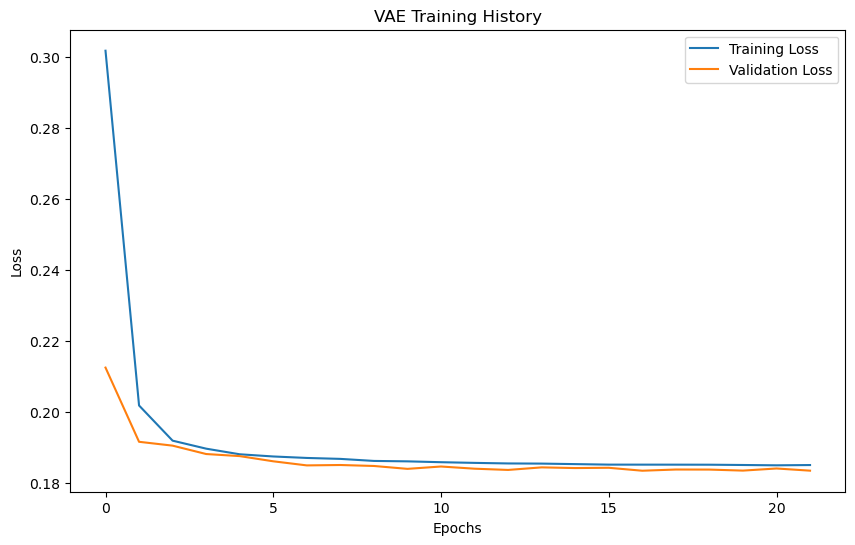

In [21]:
# Train the VAE model
# Define input dimensions based on selected features
input_dim = 8  # latitude, longitude, max_wind, min_pressure, and 4 wind radii features

# Initialize and train the model
hurricane_vae = HurricaneVAE(input_dim=input_dim, latent_dim=32)
history = hurricane_vae.train(training_data, epochs=50, batch_size=32)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('VAE Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Save the trained model
hurricane_vae.save_model('hurricane_vae_model')

# Generate synthetic hurricanes

In [22]:
# Generate synthetic hurricanes
# Let's use Hurricane Sandy as a seed
sandy_data = simulation.select_hurricane('AL182012')  # Sandy 2012

# Generate a few synthetic hurricanes based on Sandy
synthetic_hurricane = hurricane_vae.generate_synthetic_hurricane(
    num_points=60,
    seed_hurricane=sandy_data,
    randomness=0.3  # Lower value = more similar to seed
)

# Generate a completely random synthetic hurricane
# random_synthetic = hurricane_vae.generate_synthetic_hurricane(num_points=30)
# Set a specific starting location (Cape Verde type hurricane)
synthetic_hurricane = hurricane_vae.set_starting_location(
    synthetic_hurricane, 
    lat=12.5,  # 12.5°N
    lon=-25.0  # 25°W
)

# Generate a Cape Verde hurricane
cape_verde_hurricane = hurricane_vae.generate_from_region('CapeVerde', seed_hurricane=sandy_data)

# Generate a Gulf of Mexico hurricane
gulf_hurricane = hurricane_vae.generate_from_region('Gulf', seed_hurricane=sandy_data)

# Generate a Bahamas hurricane
bahamas_hurricane = hurricane_vae.generate_from_region('Bahamas', seed_hurricane=sandy_data)

# Generate a Main Development Region hurricane
mdr_hurricane = hurricane_vae.generate_from_region('MDR', seed_hurricane=sandy_data)

Selected Hurricane: AL182012, SANDY
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


# Visualize the original and synthetic hurricanes

In [23]:
# Visualize the original and synthetic hurricanes
def plot_hurricane_comparison(original_df, synthetic_df, title="Hurricane Comparison"):
    fig = plt.figure(figsize=(15, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.STATES, linestyle=':')
    ax.set_extent([-100, -50, 10, 50], crs=ccrs.PlateCarree())

    # Add OpenStreetMap base map
    osm_tiles = cimgt.OSM()
    ax.add_image(osm_tiles, 8)

    # Plot original hurricane path
    plt.plot(original_df['longitude'], original_df['latitude'],
             '-o', color='blue', markersize=4, 
             label=f"Original: {original_df['storm_name'].iloc[0]}", 
             transform=ccrs.PlateCarree())
    
    # Plot synthetic hurricane path
    plt.plot(synthetic_df['longitude'], synthetic_df['latitude'],
             '-o', color='red', markersize=4, 
             label=f"Synthetic: {synthetic_df['storm_name'].iloc[0]}", 
             transform=ccrs.PlateCarree())

    # Color points by intensity for both
    orig_scatter = plt.scatter(original_df['longitude'], original_df['latitude'], 
                          c=original_df['max_wind'], cmap='Blues', 
                          transform=ccrs.PlateCarree())
    
    syn_scatter = plt.scatter(synthetic_df['longitude'], synthetic_df['latitude'], 
                         c=synthetic_df['max_wind'], cmap='Reds', 
                         transform=ccrs.PlateCarree())

    # Add colorbars
    plt.colorbar(orig_scatter, ax=ax, label='Original Hurricane Wind Speed (knots)', shrink=0.4)
    plt.colorbar(syn_scatter, ax=ax, label='Synthetic Hurricane Wind Speed (knots)', shrink=0.4)

    plt.title(title)
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

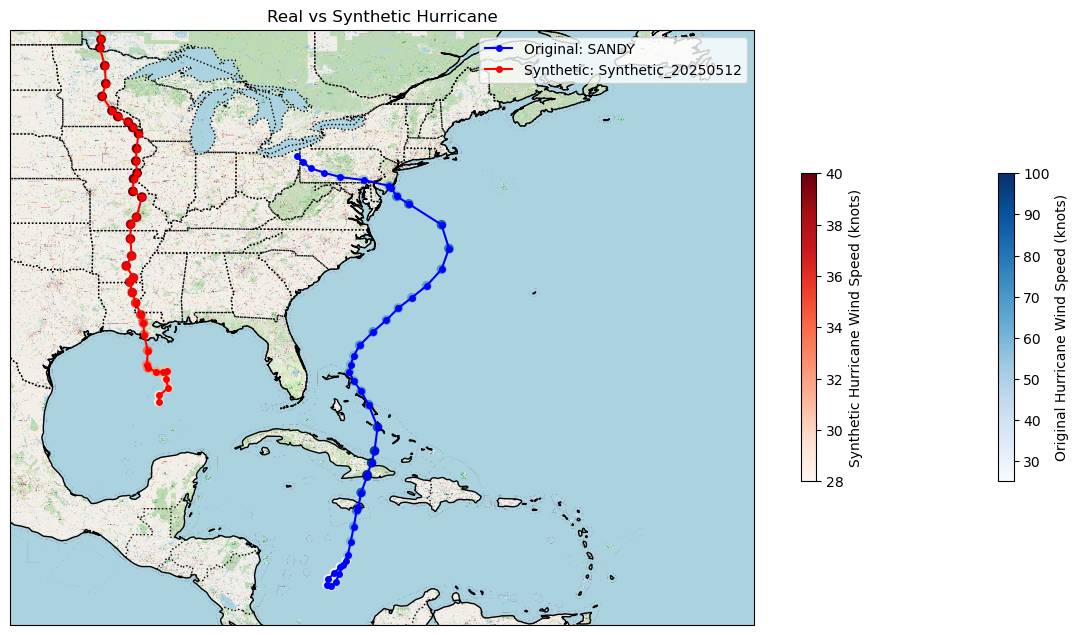

In [24]:
# Plot comparison
plot_hurricane_comparison(sandy_data, gulf_hurricane, "Real vs Synthetic Hurricane")

<urlopen error [Errno 60] Operation timed out>


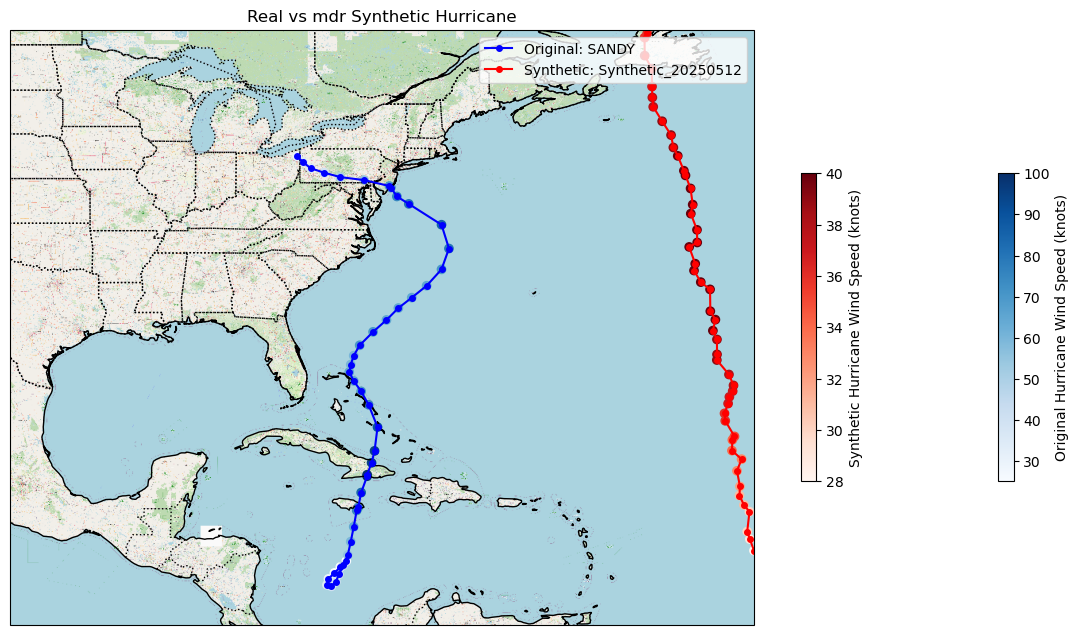

In [25]:
plot_hurricane_comparison(sandy_data, mdr_hurricane, "Real vs mdr Synthetic Hurricane")

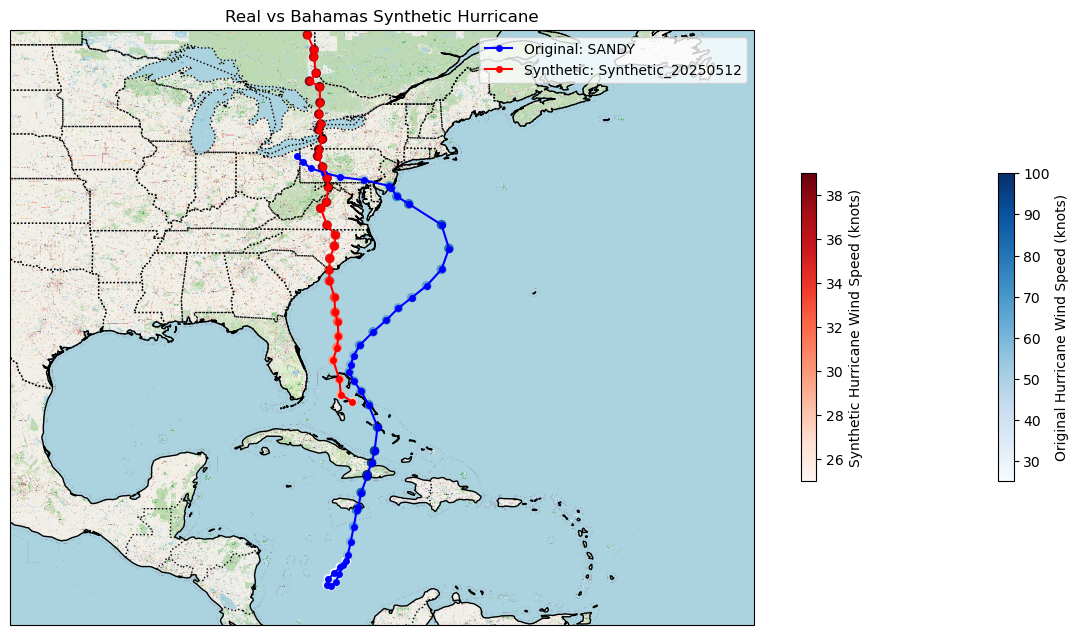

In [26]:
plot_hurricane_comparison(sandy_data, bahamas_hurricane, "Real vs Bahamas Synthetic Hurricane")

# Analyze the synthetic hurricane's impact on the wind farm

Hurricane report generated and saved to synthetic_hurricane_report.csv


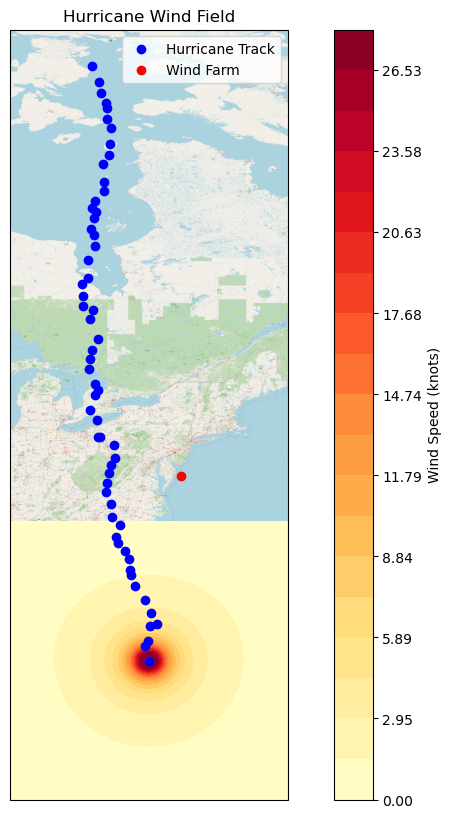

In [13]:
# Analyze the synthetic hurricane's impact on wind farm
# Create a temporary hurricane simulation for the synthetic hurricane
class SyntheticHurricaneSimulation(HurricaneSimulation):
    def __init__(self, synthetic_df, wind_farm_lat, wind_farm_lon, turbine_height=150):
        self.wind_farm_lat = wind_farm_lat
        self.wind_farm_lon = wind_farm_lon
        self.turbine_height = turbine_height
        self.hurdat_df = synthetic_df
        
# Analyze synthetic hurricane
synthetic_sim = SyntheticHurricaneSimulation(
    bahamas_hurricane,
    wind_farm_lat,
    wind_farm_lon
)

# Calculate wind speed over time for the synthetic hurricane
synthetic_with_wind = synthetic_sim.estimate_wind_speed_over_time(bahamas_hurricane)

# Generate hurricane report
synthetic_sim.generate_hurricane_report(
    synthetic_with_wind, 
    output_file='synthetic_hurricane_report.csv'
)

# Plot wind field
synthetic_sim.plot_wind_field(bahamas_hurricane)

# Generate multiple synthetic hurricanes with varying parameters

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


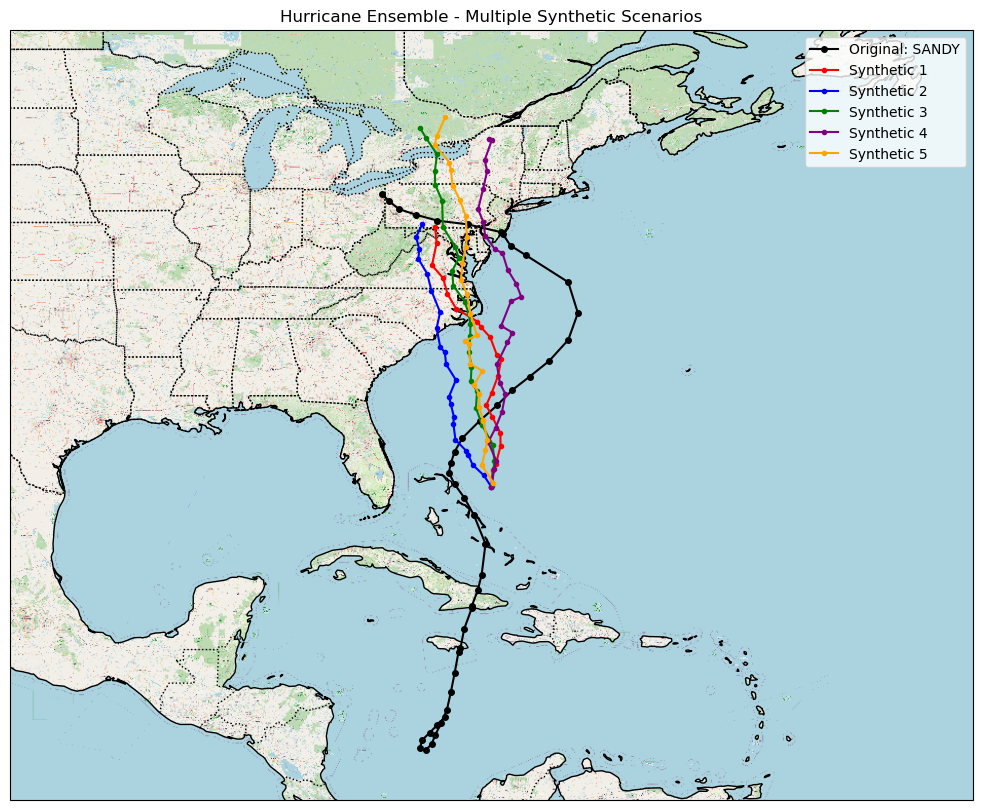

In [14]:
# Generate multiple synthetic hurricanes with varying parameters
def generate_hurricane_ensemble(vae_model, num_hurricanes=5, base_hurricane=None):
    """
    Generate an ensemble of synthetic hurricanes with different characteristics
    """
    hurricanes = []
    
    for i in range(num_hurricanes):
        # Vary randomness level for each hurricane
        randomness = 0.1 + (i * 0.15)  # 0.1, 0.25, 0.4, 0.55, 0.7
        
        synthetic = vae_model.generate_synthetic_hurricane(
            num_points=20 + i*2,  # Vary the length too
            seed_hurricane=base_hurricane,
            randomness=randomness
        )
        
        # Add ensemble member ID
        synthetic['ensemble_id'] = i
        hurricanes.append(synthetic)
    
    return hurricanes

# Generate hurricane ensemble
hurricane_ensemble = generate_hurricane_ensemble(hurricane_vae, num_hurricanes=5, base_hurricane=sandy_data)

# Visualize the ensemble
fig = plt.figure(figsize=(15, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.add_feature(cfeature.STATES, linestyle=':')
ax.set_extent([-100, -50, 10, 50], crs=ccrs.PlateCarree())

# Add OpenStreetMap base map
osm_tiles = cimgt.OSM()
ax.add_image(osm_tiles, 8)

# Plot original hurricane in black
plt.plot(sandy_data['longitude'], sandy_data['latitude'],
         '-o', color='black', markersize=4, 
         label=f"Original: {sandy_data['storm_name'].iloc[0]}", 
         transform=ccrs.PlateCarree())

# Plot each synthetic hurricane with a different color
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i, hurricane in enumerate(hurricane_ensemble):
    plt.plot(hurricane['longitude'], hurricane['latitude'],
             '-o', color=colors[i % len(colors)], markersize=3, 
             label=f"Synthetic {i+1}", 
             transform=ccrs.PlateCarree())

plt.title("Hurricane Ensemble - Multiple Synthetic Scenarios")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

# Validation of synthetic hurricanes

In [19]:
def validate_synthetic_hurricanes(synthetic_hurricanes, historical_hurricanes):
    """
    Validate synthetic hurricanes against historical data
    
    Parameters:
    -----------
    synthetic_hurricanes: list of DataFrames
        List of synthetic hurricane DataFrames
    historical_hurricanes: DataFrame
        Historical hurricane data for comparison
    """
    from scipy import stats
    import matplotlib.pyplot as plt
    from math import radians, sin, cos, sqrt, atan2
    
    # 1. Statistical validation
    
    # Combine synthetic hurricanes
    synthetic_combined = pd.concat(synthetic_hurricanes, ignore_index=True)
    
    # Key parameters to validate
    params = ['max_wind', 'min_pressure', 'latitude', 'longitude']
    
    # Store test results
    ks_tests = {}
    
    fig, axes = plt.subplots(len(params), 2, figsize=(15, 5*len(params)))
    
    for i, param in enumerate(params):
        # Distribution comparison
        hist_values = historical_hurricanes[param].dropna().values
        syn_values = synthetic_combined[param].dropna().values
        
        # KS test
        ks_stat, p_value = stats.ks_2samp(hist_values, syn_values)
        ks_tests[param] = (ks_stat, p_value)
        
        # Histogram comparison
        axes[i, 0].hist(hist_values, bins=30, alpha=0.5, label='Historical')
        axes[i, 0].hist(syn_values, bins=30, alpha=0.5, label='Synthetic')
        axes[i, 0].set_title(f'{param} Distribution - KS p-value: {p_value:.4f}')
        axes[i, 0].legend()
        
        # Q-Q plot with same size arrays
        hist_percentiles = np.percentile(hist_values, np.linspace(0, 100, 100))
        syn_percentiles = np.percentile(syn_values, np.linspace(0, 100, 100))
        
        axes[i, 1].scatter(hist_percentiles, syn_percentiles)
        
        # Create a reference line with min and max of the percentiles
        min_val = min(hist_percentiles.min(), syn_percentiles.min())
        max_val = max(hist_percentiles.max(), syn_percentiles.max())
        axes[i, 1].plot([min_val, max_val], [min_val, max_val], 'r--')
        
        axes[i, 1].set_xlabel('Historical Quantiles')
        axes[i, 1].set_ylabel('Synthetic Quantiles')
        axes[i, 1].set_title(f'Q-Q Plot for {param}')
    
    plt.tight_layout()
    plt.show()
    
    # 2. Track characteristic validation
    def haversine_distance(lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * atan2(sqrt(a), sqrt(1-a))
        distance = 6371 * c  # Earth radius in km
        return distance
    
    track_metrics = []
    
    for i, hurricane in enumerate(synthetic_hurricanes):
        # Calculate track sinuosity (total path length / direct distance)
        lats = hurricane['latitude'].values
        lons = hurricane['longitude'].values
        
        # Calculate path length
        path_length = 0
        for j in range(1, len(lats)):
            path_length += haversine_distance(lats[j-1], lons[j-1], lats[j], lons[j])
            
        # Calculate direct distance from start to end
        direct_dist = haversine_distance(lats[0], lons[0], lats[-1], lons[-1])
        sinuosity = path_length / direct_dist if direct_dist > 0 else np.nan
        
        # Calculate average translation speed if datetime is available
        if 'datetime' in hurricane.columns:
            # Calculate time differences in hours
            time_diffs = []
            for j in range(1, len(hurricane)):
                diff = (hurricane['datetime'].iloc[j] - hurricane['datetime'].iloc[j-1]).total_seconds() / 3600
                time_diffs.append(diff)
                
            # Calculate distances between consecutive points
            distances = []
            for j in range(1, len(lats)):
                distances.append(haversine_distance(lats[j-1], lons[j-1], lats[j], lons[j]))
                
            if len(time_diffs) > 0 and len(distances) > 0:
                avg_speed = np.mean(np.array(distances) / np.array(time_diffs))
            else:
                avg_speed = np.nan
        else:
            avg_speed = np.nan
        
        track_metrics.append({
            'hurricane_id': hurricane['full_id'].iloc[0] if 'full_id' in hurricane.columns else f'Synthetic_{i}',
            'sinuosity': sinuosity,
            'avg_translation_speed': avg_speed,
            'max_wind_mean': hurricane['max_wind'].mean(),
            'min_pressure_mean': hurricane['min_pressure'].mean() if 'min_pressure' in hurricane.columns else np.nan
        })
    
    track_df = pd.DataFrame(track_metrics)
    
    # 3. Physical relationship validation - Wind-pressure relationship
    plt.figure(figsize=(10, 6))
    plt.scatter(historical_hurricanes['max_wind'], historical_hurricanes['min_pressure'], 
                alpha=0.4, label='Historical', color='blue')
    plt.scatter(synthetic_combined['max_wind'], synthetic_combined['min_pressure'], 
                alpha=0.4, label='Synthetic', color='red')
    
    plt.xlabel('Maximum Wind Speed (knots)')
    plt.ylabel('Minimum Pressure (hPa)')
    plt.title('Wind-Pressure Relationship')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # Return validation results
    return {
        'ks_tests': ks_tests,
        'track_metrics': track_df
    }

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


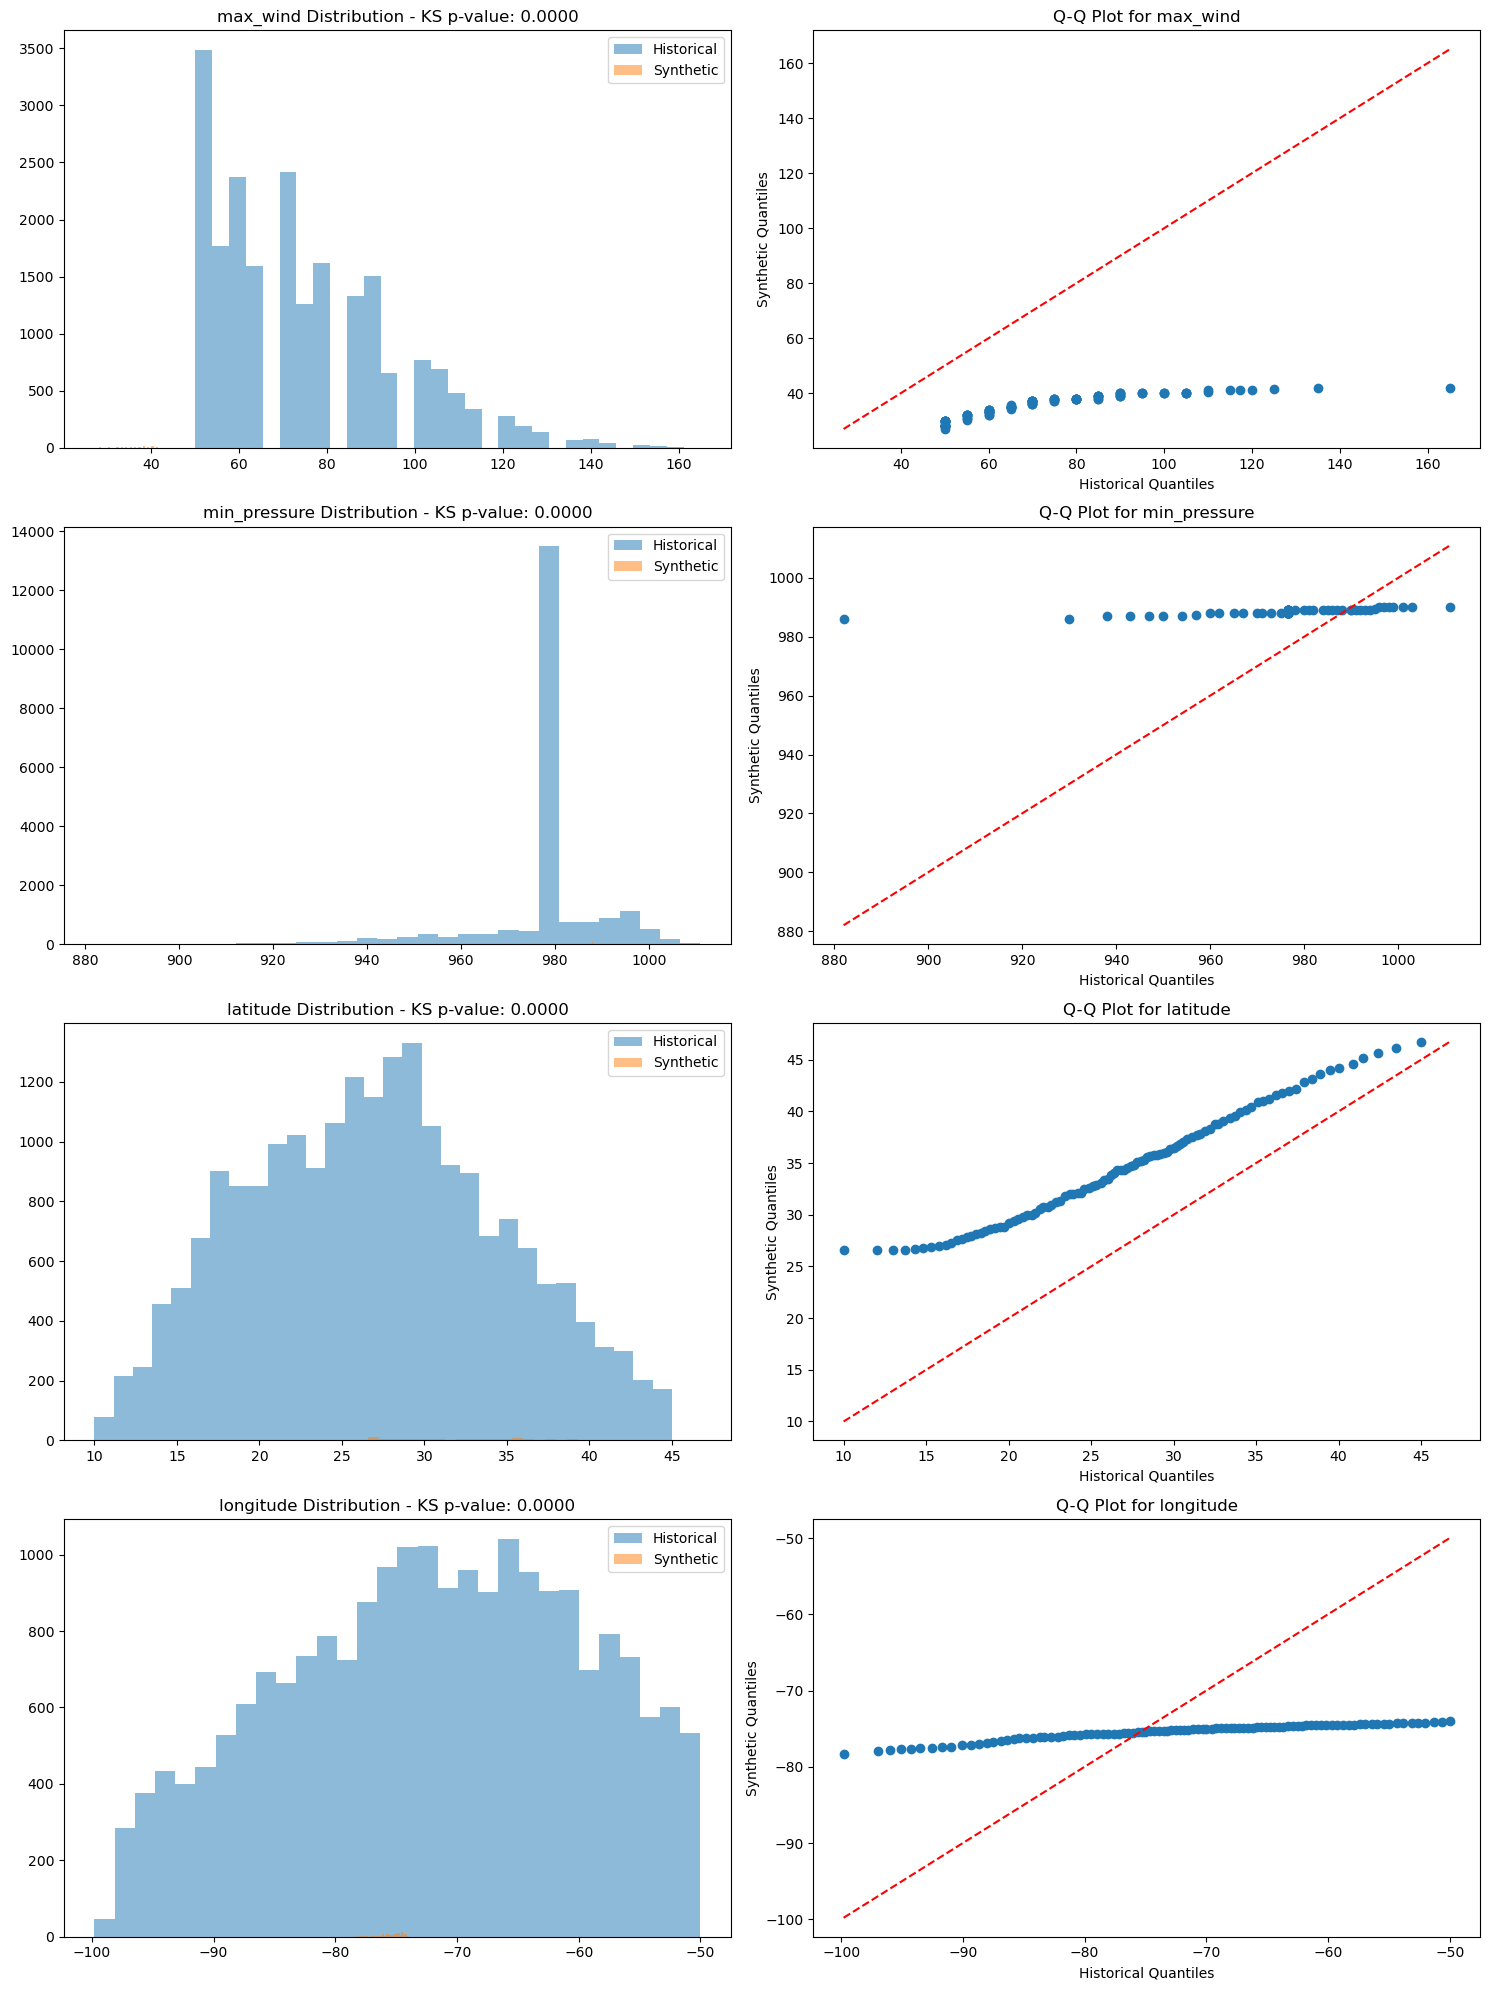

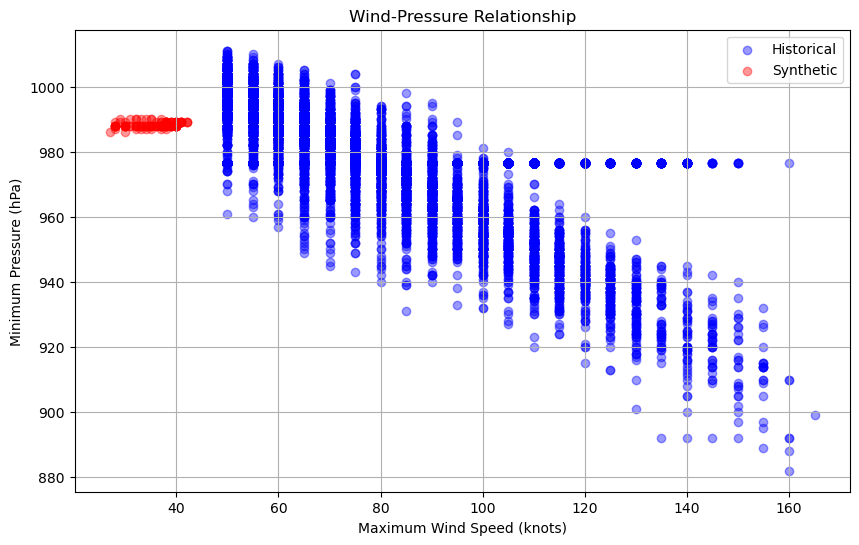


Kolmogorov-Smirnov Test Results:
max_wind: statistic=1.0000, p-value=0.0000
min_pressure: statistic=0.8322, p-value=0.0000
latitude: statistic=0.4829, p-value=0.0000
longitude: statistic=0.5707, p-value=0.0000

Track Metrics Summary:
  hurricane_id  sinuosity  avg_translation_speed  max_wind_mean  \
0    SYN202505   1.103730              14.623265      35.400000   
1    SYN202505   1.178897              12.328413      35.727273   
2    SYN202505   1.045695              15.866704      35.916667   
3    SYN202505   1.048251              13.947526      34.769231   
4    SYN202505   1.045882              14.482905      36.250000   

   min_pressure_mean  
0         988.000000  
1         988.000000  
2         988.875000  
3         988.769231  
4         988.000000  


In [27]:
# First, generate multiple synthetic hurricanes (you already have code for this)
hurricane_ensemble = generate_hurricane_ensemble(hurricane_vae, num_hurricanes=5, base_hurricane=sandy_data)

# Run the validation function
validation_results = validate_synthetic_hurricanes(
    synthetic_hurricanes=hurricane_ensemble,  # List of your synthetic hurricane DataFrames
    historical_hurricanes=training_data       # Historical data (you already created this)
)

# Print the statistical test results
print("\nKolmogorov-Smirnov Test Results:")
for param, (stat, p_value) in validation_results['ks_tests'].items():
    print(f"{param}: statistic={stat:.4f}, p-value={p_value:.4f}")

# Examine track metrics summary statistics
print("\nTrack Metrics Summary:")
print(validation_results['track_metrics'])